# priors on the ALPT non-local bias parameters

Lets set the prior range for all the ALPT non-local bias model parameters. The main philosophy will be to find a range that comfortably encompasses the fiducial Quijote+HOD clustering. 

In [1]:
import numpy as np

In [2]:
from hodalpt import priors
from hodalpt.sims import alpt as CS
from nbodykit.lab import ArrayCatalog, FFTPower

In [3]:
import matplotlib.pyplot as plt

In [4]:
import copy

## fiducial Quijote+HOD clustering
This is based on the ~MAP of HOD constraints from the bispectrum

In [5]:
from hodalpt.sims.quijote import HODgalaxies
theta_hod = {}
theta_hod['logMmin'] = 13.0
theta_hod['sigma_logM'] = 0.4
theta_hod['logM0'] = 13.67
theta_hod['logM1'] = 13.68
theta_hod['alpha'] = 0.79
theta_hod['Abias'] = 0.0
theta_hod['eta_conc'] = 1.11
theta_hod['eta_cen'] = 0.31
theta_hod['eta_sat'] = 0.85

hod = HODgalaxies(theta_hod, '/Users/ch54662/data/simbig/quijote/fiducial_HR/0')

_cat = ArrayCatalog({'Position': np.array(hod['Position'])}, BoxSize=1000.) 
r_hod = FFTPower(_cat, mode='1d', Nmesh=256, dk=0.005, kmin=0.008, los=[0,0,1], poles=[0])

/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/phase_space_models/analytic_models/satellites/nfw/biased_nfw_phase_space.py:225: UserWarning: You have selected 18 bins to digitize host halo concentration 
and 96 bins to digitize the galaxy bias parameter.
To populate mocks, the BiasedNFWPhaseSpace class builds a lookup table with shape (18, 96, 101),
one entry for every numerical solution to the Jeans equation.
Using this fine of a binning requires a long pre-computation of 174528 integrals
.Make sure you actually need to use so many bins
  warn(lookup_table_performance_warning.format(*args))
/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/factories/hod_model_factory.py:890: UserWarning: The composite model received multiple component models 
with a new_haloprop_func_dict that use the conc_NFWmodel key. 
Ignoring the one that appears in the profile component for satellite

In [6]:
ng_hod = np.array(hod['Position']).shape[0]

In [7]:
print(ng_hod)

424839


In [8]:
def alpt_pk(tt, bias_model='nonlocal2'): 
    xyz = CS.CSbox_galaxy(tt, {}, '/Users/ch54662/data/simbig/quijote/fiducial_HR/0/alpt/', 
                              bias_model=bias_model, rsd=False, subgrid=True, silent=True)
    _cat = ArrayCatalog({'Position': xyz}, BoxSize=1000.) 
    r = FFTPower(_cat, mode='1d', Nmesh=256, dk=0.005, kmin=0.008, los=[0,0,1], poles=[0])
    return r.poles['k'], r.poles['power_0'].real - r.poles.attrs['shotnoise'], xyz.shape[0]

def alpt_pk_rsd(tt, tt_rsd): 
    xyz = CS.CSbox_galaxy(tt, tt_rsd, '/Users/ch54662/data/simbig/quijote/fiducial_HR/0/alpt/', 
                              bias_model='nonlocal2', rsd=True, subgrid=True, silent=True)
    
    _cat = ArrayCatalog({'Position': xyz}, BoxSize=1000.) 
    r = FFTPower(_cat, mode='1d', Nmesh=256, dk=0.005, kmin=0.008, los=[0,0,1], poles=[0])
    return r.poles['k'], r.poles['power_0'].real - r.poles.attrs['shotnoise'], xyz.shape[0]    

In [9]:
_nmeans, _alphas, _betas, _dth, _rhoeps, _eps = np.loadtxt('/Users/ch54662/projects/hodalpt/src/hodalpt/sims/dat/bias_quij_fits.txt', skiprows=1, delimiter=',', unpack=True)

In [10]:
theta = {}
theta['nmean'] = _nmeans.reshape((3,4))
theta['alpha'] = _alphas.reshape((3,4))
theta['beta'] = _betas.reshape((3,4))
theta['dth'] = _dth.reshape((3,4))
theta['rhoeps'] = _rhoeps.reshape((3,4))
theta['eps'] = _eps.reshape((3,4))

theta_rsd = {} 
theta_rsd['bv'] = 0.7289
theta_rsd['bb'] = 1.1652 # scaling of RSD sigma
theta_rsd['betarsd'] = 1.3136 # density dependence
theta_rsd['gamma'] = 0.4944 # expoential control over vleocity

In [11]:
theta

{'nmean': array([[9.8537e-05, 4.2518e-05, 3.3140e-06, 6.0000e-09],
        [5.7186e-05, 1.5255e-04, 3.7179e-05, 4.1800e-07],
        [3.7550e-06, 1.6143e-05, 1.3051e-05, 3.4600e-07]]),
 'alpha': array([[2.55507587, 2.47295497, 2.73205651, 1.84127505],
        [1.51404611, 1.56002301, 1.82063634, 2.24222174],
        [0.89251128, 1.84418847, 1.66726894, 1.8728944 ]]),
 'beta': array([[46.52266564,  0.95479372, 38.98254515, 43.30494003],
        [89.54611296,  2.86141137, 46.93613101, 29.67156151],
        [19.97725506, 10.17109544, 96.30406539,  0.64349124]]),
 'dth': array([[-0.21905432,  0.13138295, -0.15471376, -0.48299674],
        [-0.22557302, -0.49005921,  0.06616824, -0.4996209 ],
        [-0.49076101, -0.30928317,  0.22976504, -0.42312753]]),
 'rhoeps': array([[ 2.35471611,  8.18858541,  7.88596052, 18.57024831],
        [ 2.53350613, 13.25924897, 12.74571298,  4.49519201],
        [13.78537504, 16.64797139, 13.40960105, 10.87611881]]),
 'eps': array([[1.42032856, 2.13095791, 2

In [12]:
k, p0k_fid, ng_fid = alpt_pk(theta)
_, p0k_rsd, _ = alpt_pk_rsd(theta, theta_rsd)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [13]:
ng_fid, ng_hod

(424264, 424839)

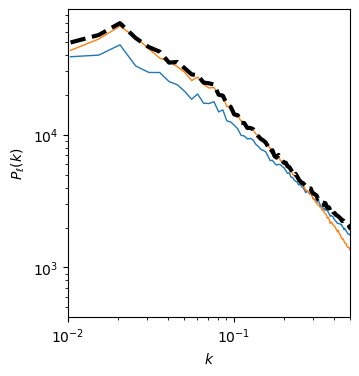

In [14]:
fig = plt.figure(figsize=(8,4))
sub = fig.add_subplot(121)

sub.plot(k, p0k_fid, c='C0', lw=1)    
sub.plot(k, p0k_rsd, c='C1', lw=1)    
sub.plot(r_hod.poles['k'], (r_hod.poles['power_0'].real - r_hod.poles.attrs['shotnoise']), c='k', ls='--', lw=3)

sub.set_xlabel('$k$')
sub.set_xlim(1e-2, 0.5)
sub.set_xscale('log')
sub.set_ylabel('$P_\ell(k)$')
sub.set_yscale('log')
#sub.set_ylim(-1e3, 4e3)

# examine derivatives of bias parameters

alpha knot knot 425141 425281


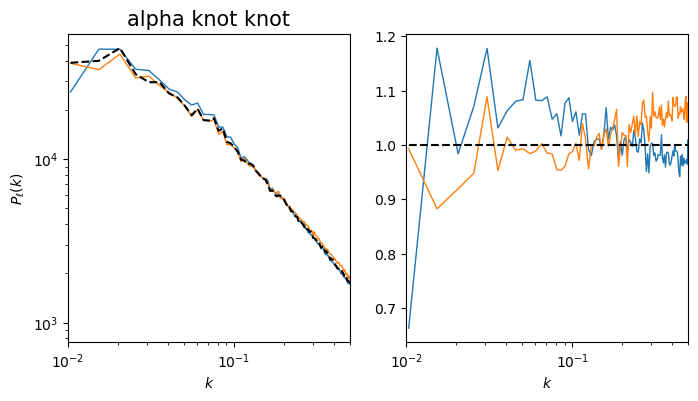

alpha knot filament 425960 423504


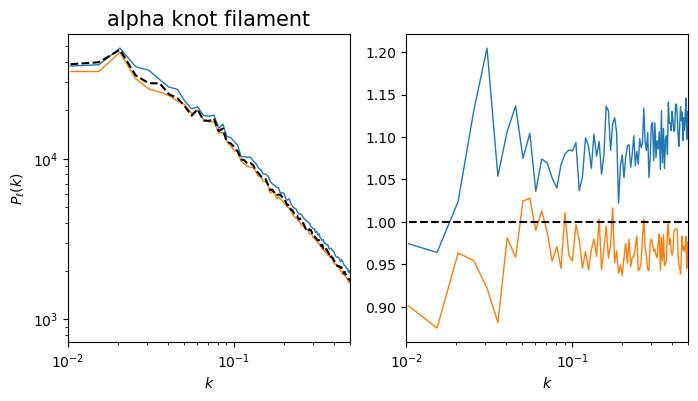

alpha knot sheet 424124 425287


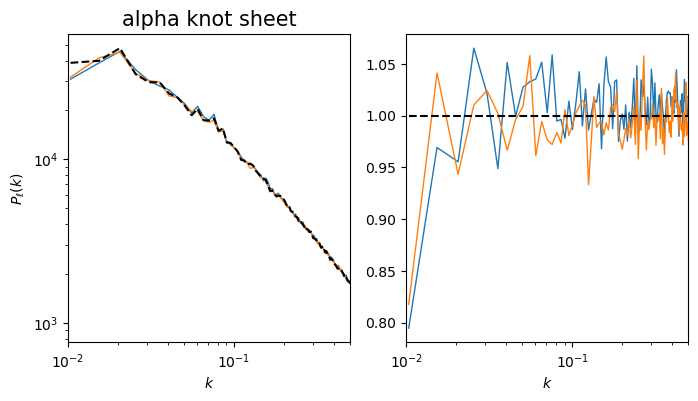

alpha knot void 425228 425497


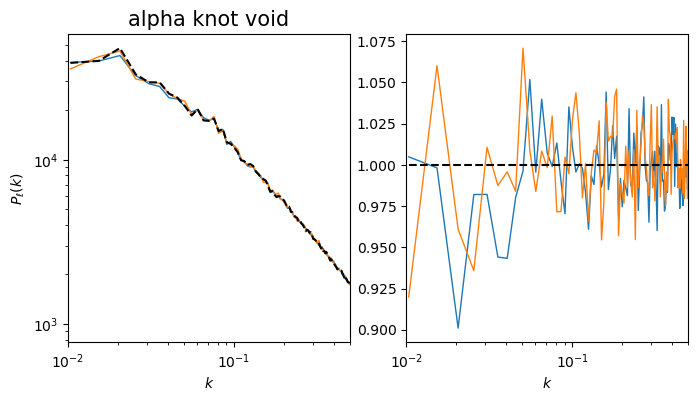

alpha filament knot 424970 424514


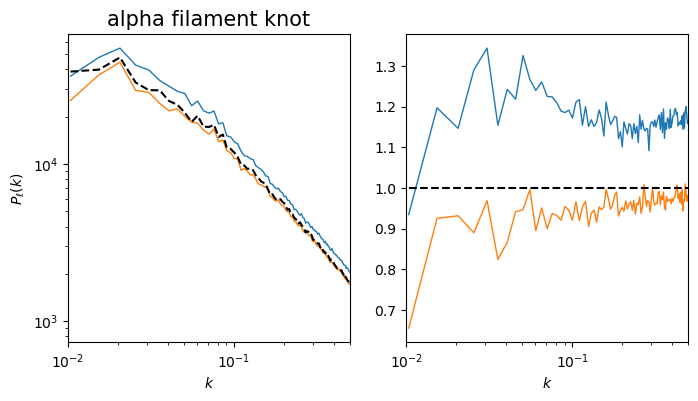

alpha filament filament 424146 426367


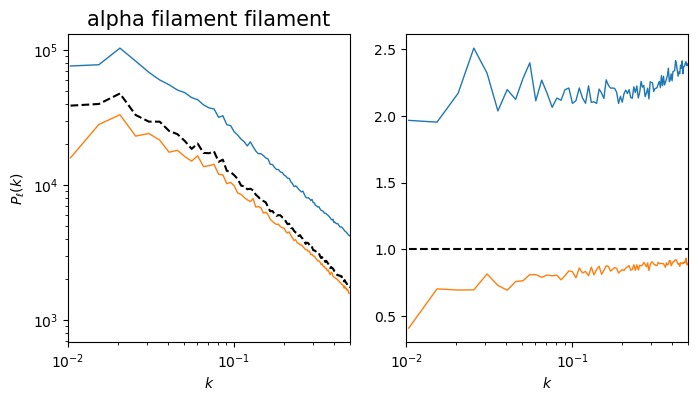

alpha filament sheet 423970 424668


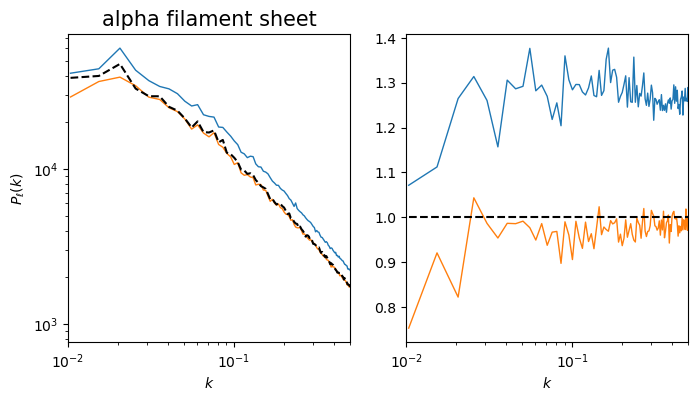

alpha filament void 425883 424547


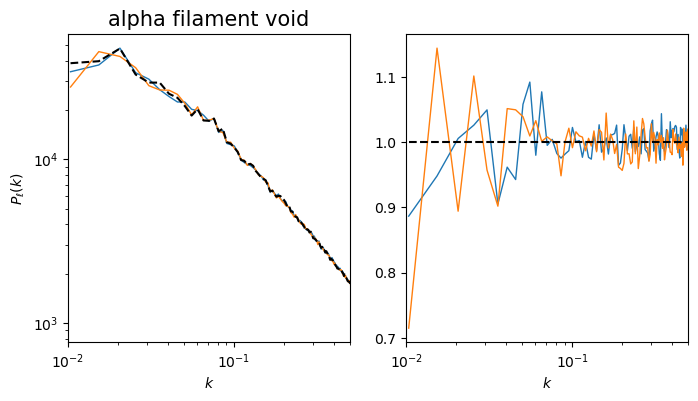

alpha sheet knot 424077 425307


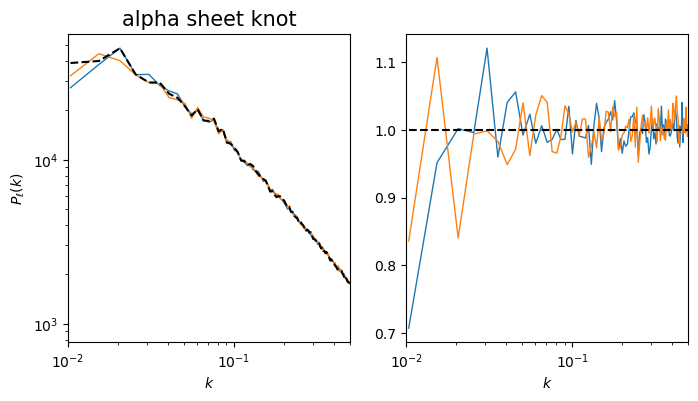

alpha sheet filament 425265 424178


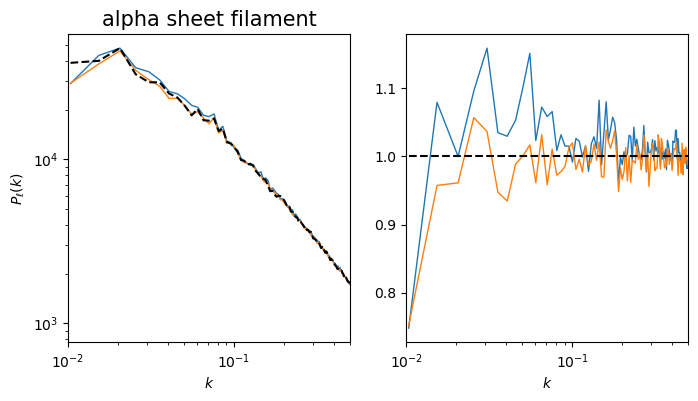

alpha sheet sheet 424019 425026


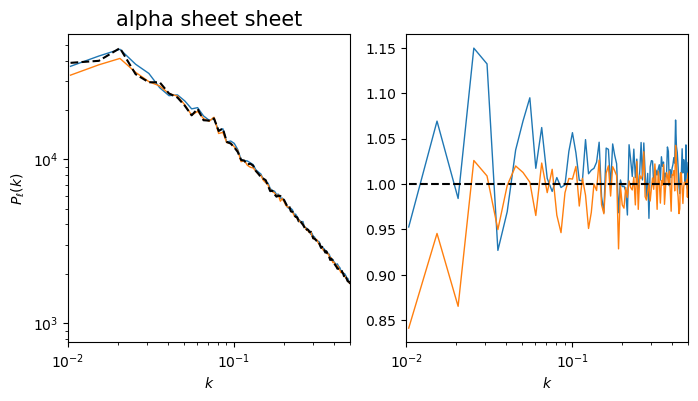

alpha sheet void 424922 423964


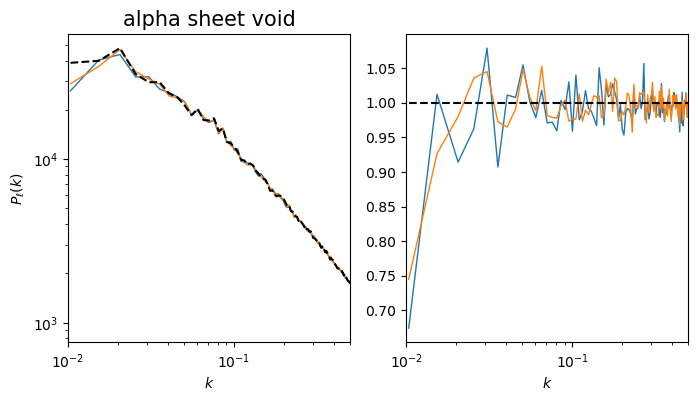

In [15]:
key = 'alpha'
for ienv in range(3): 
    for jenv in range(4): 
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 2
        _, _p0k0, _ng0 = alpt_pk(_tt)
    
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 0.5
        _k, _p0k1, _ng1 = alpt_pk(_tt)

        print('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), _ng0, _ng1)
    
        fig = plt.figure(figsize=(8,4))
        sub = fig.add_subplot(121)
        sub.plot(k, _p0k0, c='C0', lw=1)  
        sub.plot(k, _p0k1, c='C1', lw=1)  
        sub.plot(k, p0k_fid, c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        sub.set_ylabel('$P_\ell(k)$')
        sub.set_yscale('log')
        sub.set_title('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), 
                      fontsize=15)
    
        sub = fig.add_subplot(122)
        sub.plot(k, _p0k0/p0k_fid, c='C0', lw=1)  
        sub.plot(k, _p0k1/p0k_fid, c='C1', lw=1)  
        sub.plot(k, np.ones_like(k), c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        plt.show()

[[4.92685e-05 4.25180e-05 3.31400e-06 6.00000e-09]
 [5.71860e-05 1.52550e-04 3.71790e-05 4.18000e-07]
 [3.75500e-06 1.61430e-05 1.30510e-05 3.46000e-07]]
nmean knot knot 523088 375911


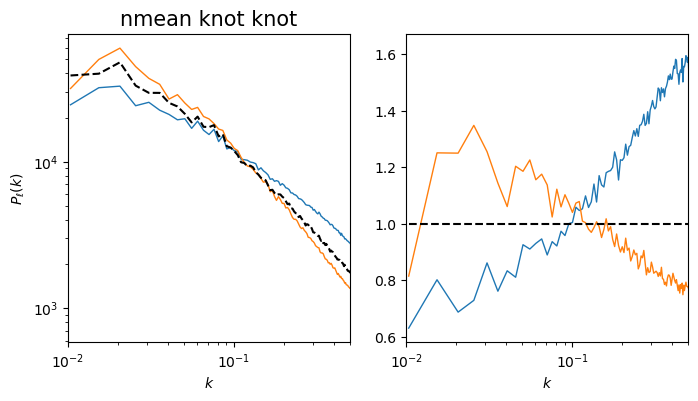

[[9.8537e-05 2.1259e-05 3.3140e-06 6.0000e-09]
 [5.7186e-05 1.5255e-04 3.7179e-05 4.1800e-07]
 [3.7550e-06 1.6143e-05 1.3051e-05 3.4600e-07]]
nmean knot filament 467097 403643


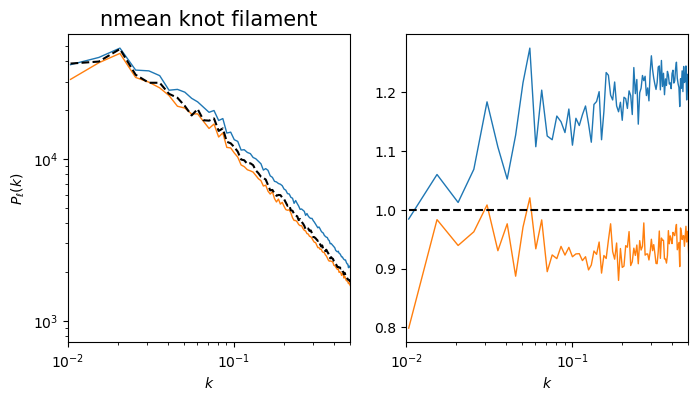

[[9.8537e-05 4.2518e-05 1.6570e-06 6.0000e-09]
 [5.7186e-05 1.5255e-04 3.7179e-05 4.1800e-07]
 [3.7550e-06 1.6143e-05 1.3051e-05 3.4600e-07]]
nmean knot sheet 428651 423271


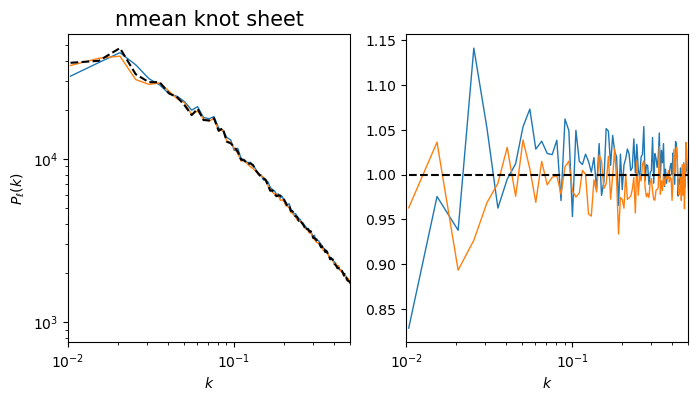

[[9.8537e-05 4.2518e-05 3.3140e-06 3.0000e-09]
 [5.7186e-05 1.5255e-04 3.7179e-05 4.1800e-07]
 [3.7550e-06 1.6143e-05 1.3051e-05 3.4600e-07]]
nmean knot void 424904 424204


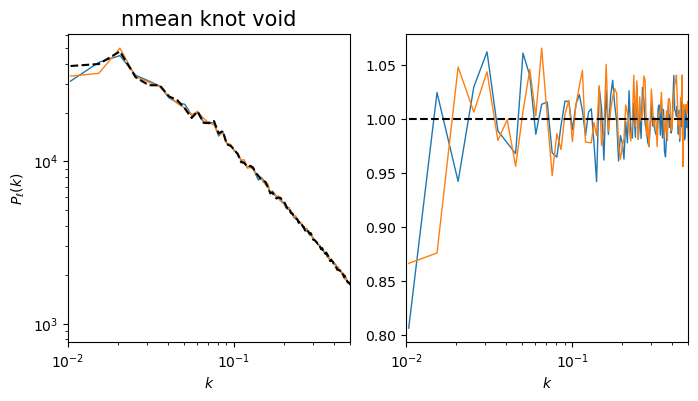

[[9.8537e-05 4.2518e-05 3.3140e-06 6.0000e-09]
 [2.8593e-05 1.5255e-04 3.7179e-05 4.1800e-07]
 [3.7550e-06 1.6143e-05 1.3051e-05 3.4600e-07]]
nmean filament knot 483020 395510


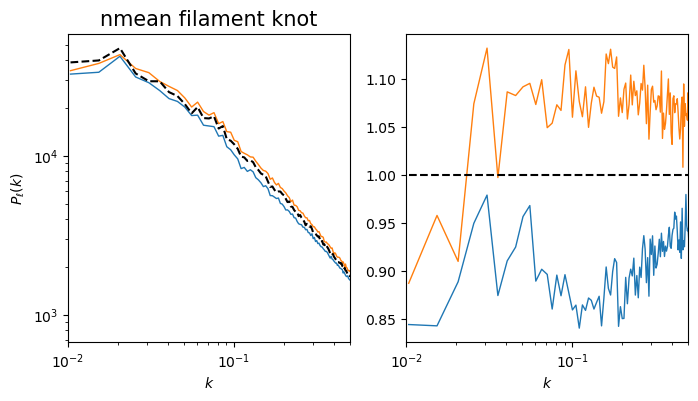

[[9.8537e-05 4.2518e-05 3.3140e-06 6.0000e-09]
 [5.7186e-05 7.6275e-05 3.7179e-05 4.1800e-07]
 [3.7550e-06 1.6143e-05 1.3051e-05 3.4600e-07]]
nmean filament filament 578740 349514


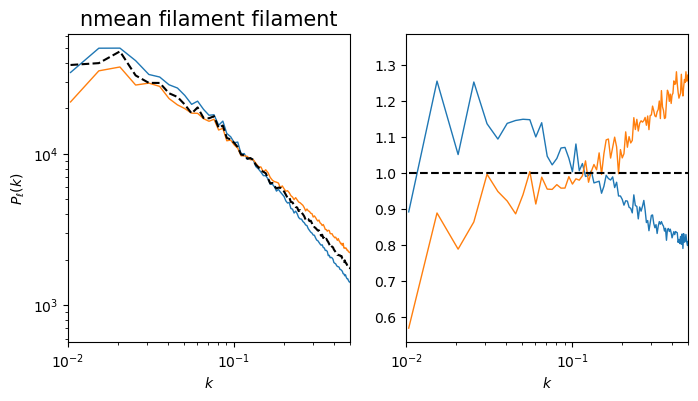

[[9.85370e-05 4.25180e-05 3.31400e-06 6.00000e-09]
 [5.71860e-05 1.52550e-04 1.85895e-05 4.18000e-07]
 [3.75500e-06 1.61430e-05 1.30510e-05 3.46000e-07]]
nmean filament sheet 462567 406457


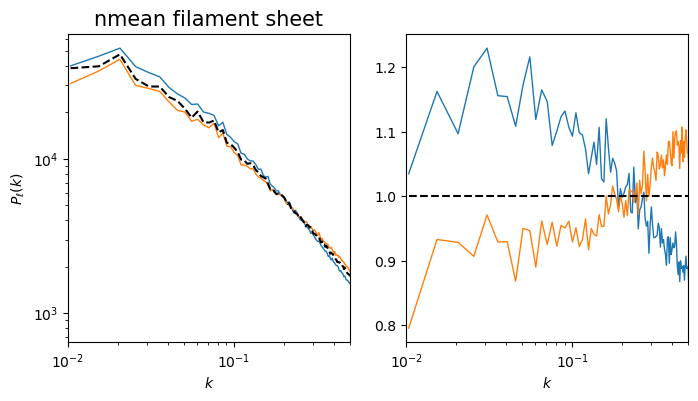

[[9.8537e-05 4.2518e-05 3.3140e-06 6.0000e-09]
 [5.7186e-05 1.5255e-04 3.7179e-05 2.0900e-07]
 [3.7550e-06 1.6143e-05 1.3051e-05 3.4600e-07]]
nmean filament void 425532 425323


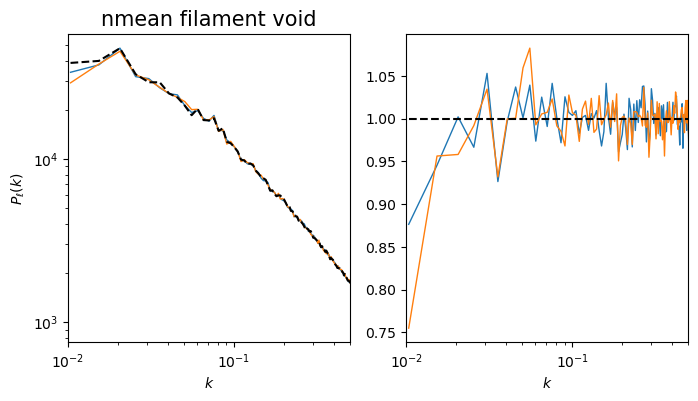

[[9.8537e-05 4.2518e-05 3.3140e-06 6.0000e-09]
 [5.7186e-05 1.5255e-04 3.7179e-05 4.1800e-07]
 [1.8775e-06 1.6143e-05 1.3051e-05 3.4600e-07]]
nmean sheet knot 429117 423556


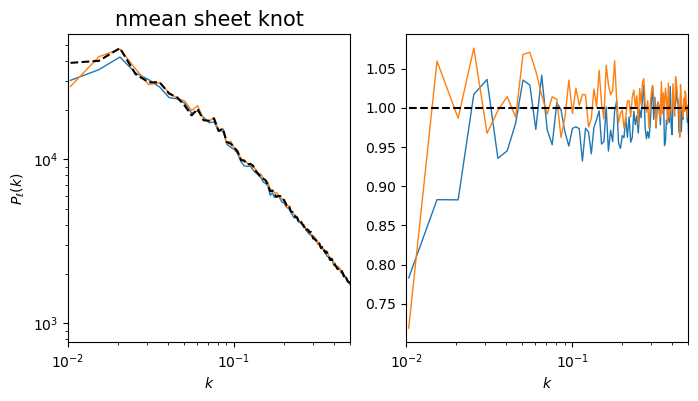

[[9.8537e-05 4.2518e-05 3.3140e-06 6.0000e-09]
 [5.7186e-05 1.5255e-04 3.7179e-05 4.1800e-07]
 [3.7550e-06 8.0715e-06 1.3051e-05 3.4600e-07]]
nmean sheet filament 440841 416289


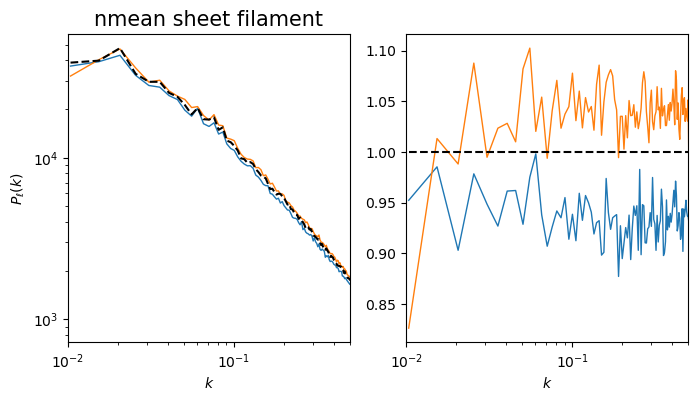

[[9.8537e-05 4.2518e-05 3.3140e-06 6.0000e-09]
 [5.7186e-05 1.5255e-04 3.7179e-05 4.1800e-07]
 [3.7550e-06 1.6143e-05 6.5255e-06 3.4600e-07]]
nmean sheet sheet 438726 419197


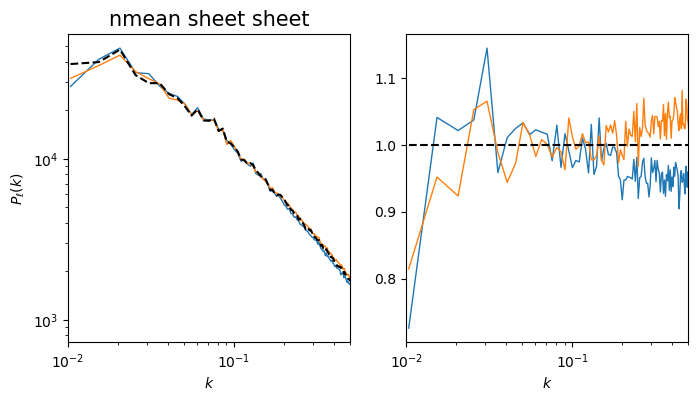

[[9.8537e-05 4.2518e-05 3.3140e-06 6.0000e-09]
 [5.7186e-05 1.5255e-04 3.7179e-05 4.1800e-07]
 [3.7550e-06 1.6143e-05 1.3051e-05 1.7300e-07]]
nmean sheet void 424830 423441


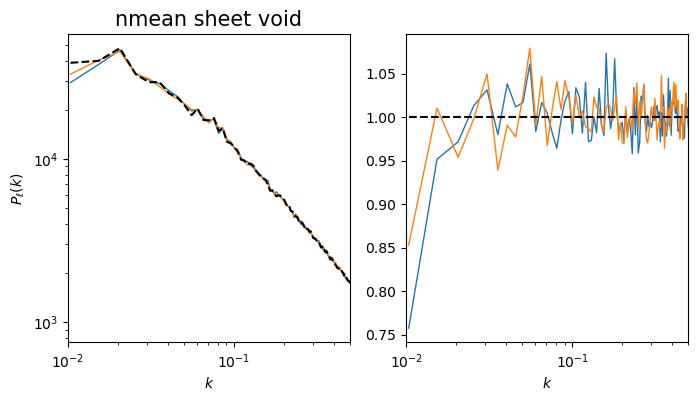

In [16]:
key = 'nmean'
for ienv in range(3): 
    for jenv in range(4): 
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 2
        _, _p0k0, _ng0 = alpt_pk(_tt)
    
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 0.5
        print(_tt[key])
        _k, _p0k1, _ng1 = alpt_pk(_tt)

        print('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), _ng0, _ng1)
    
        fig = plt.figure(figsize=(8,4))
        sub = fig.add_subplot(121)
        sub.plot(k, _p0k0, c='C0', lw=1)  
        sub.plot(k, _p0k1, c='C1', lw=1)  
        sub.plot(k, p0k_fid, c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        sub.set_ylabel('$P_\ell(k)$')
        sub.set_yscale('log')
        sub.set_title('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), 
                      fontsize=15)
    
        sub = fig.add_subplot(122)
        sub.plot(k, _p0k0/p0k_fid, c='C0', lw=1)  
        sub.plot(k, _p0k1/p0k_fid, c='C1', lw=1)  
        sub.plot(k, np.ones_like(k), c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        plt.show()

dth knot knot 424747 425131


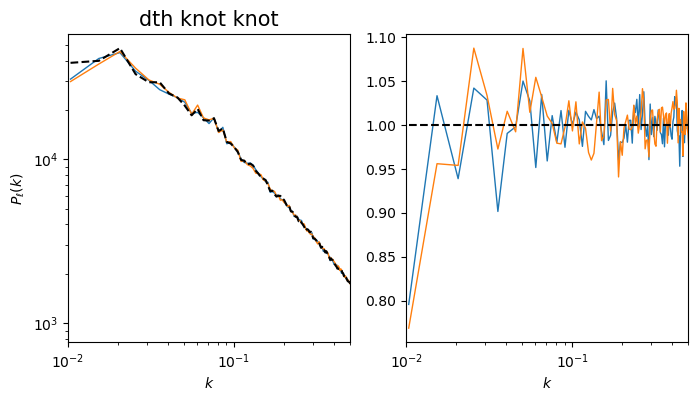

dth knot filament 424175 425405


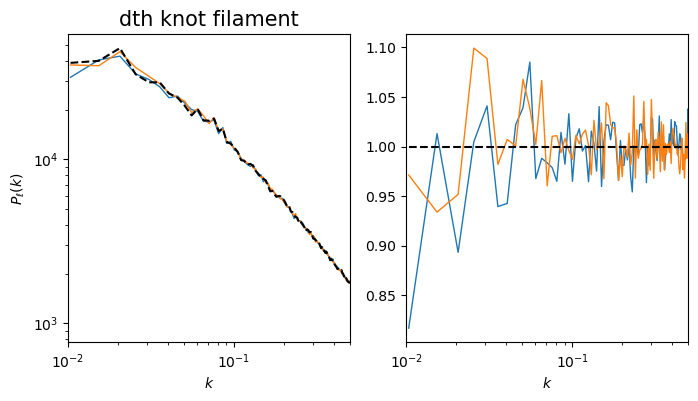

dth knot sheet 424836 425777


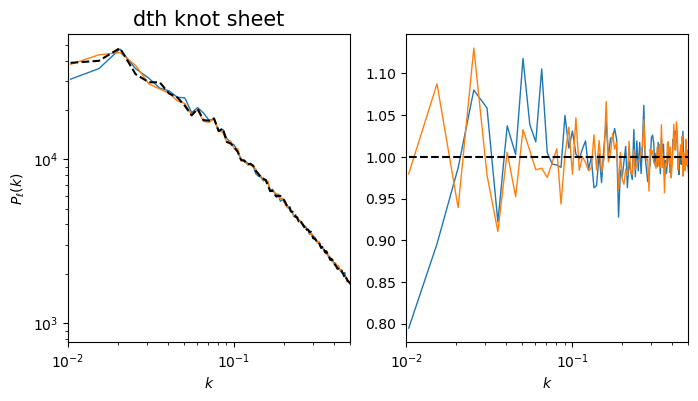

dth knot void 423715 424205


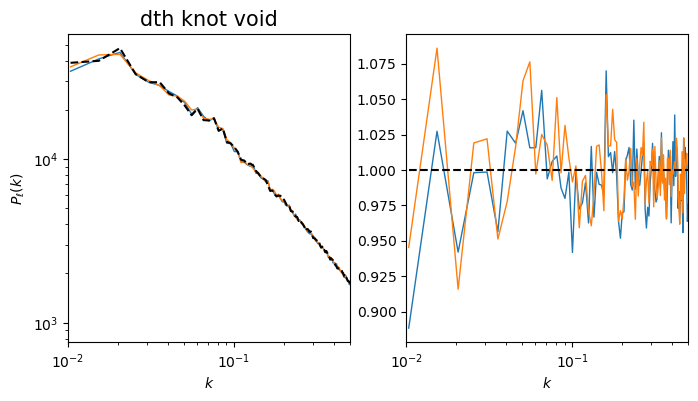

dth filament knot 424528 424777


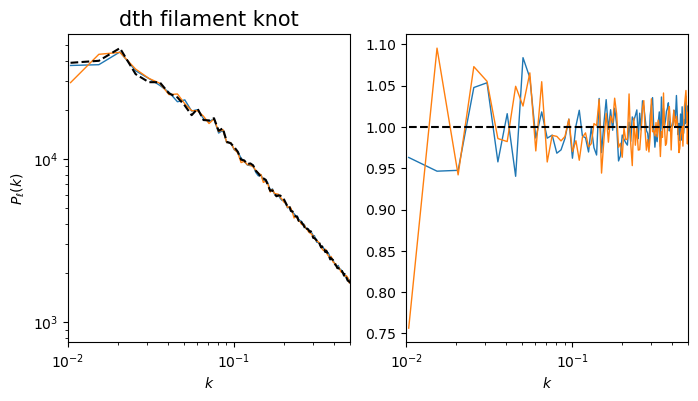

dth filament filament 424786 424239


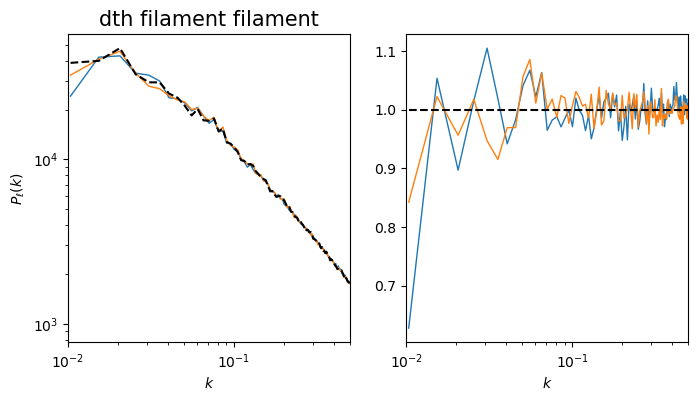

dth filament sheet 425236 425302


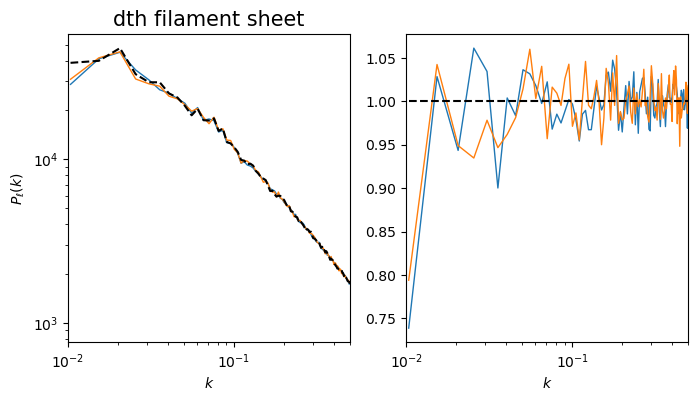

dth filament void 425040 426150


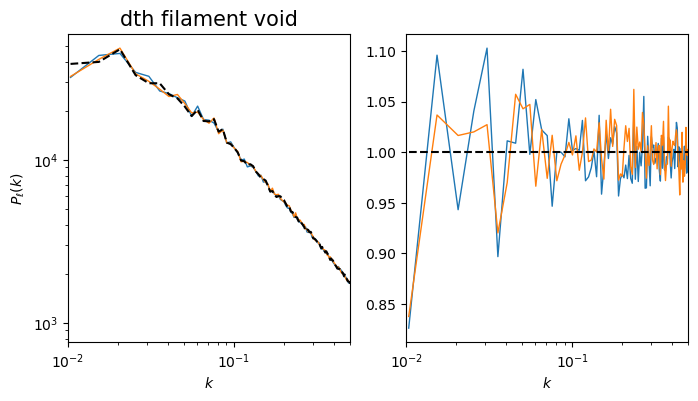

dth sheet knot 425631 424526


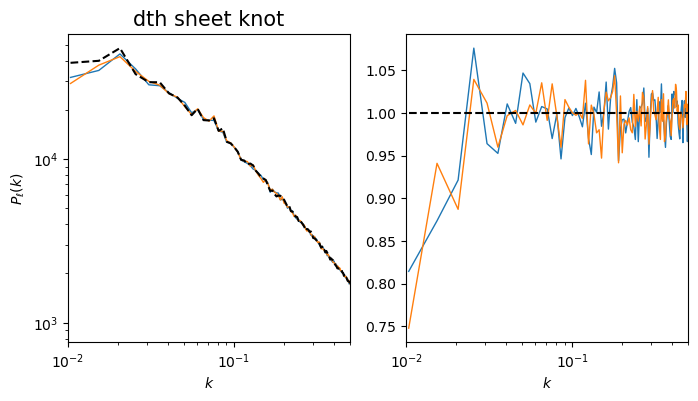

dth sheet filament 424729 424871


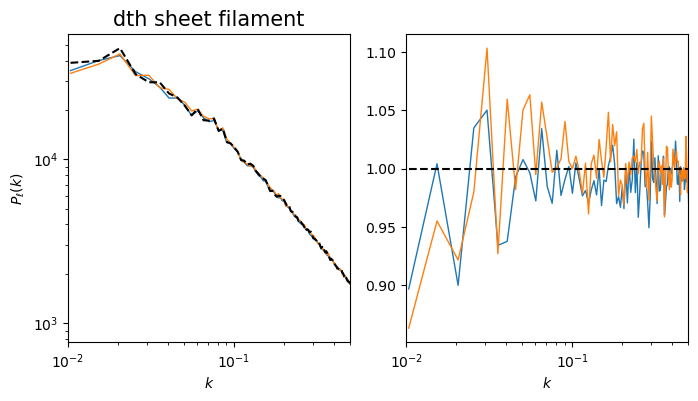

dth sheet sheet 426498 424668


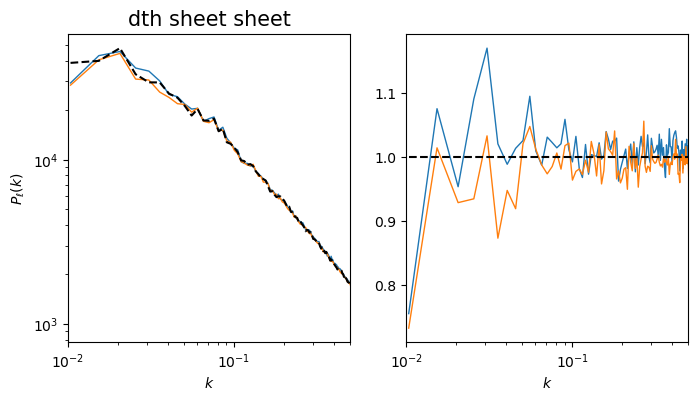

dth sheet void 424424 425058


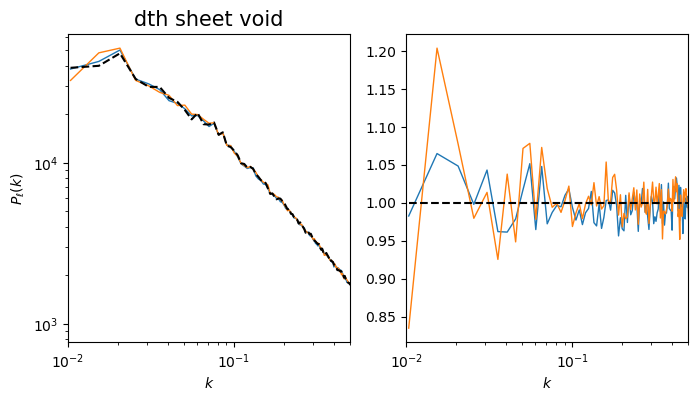

In [17]:
key = 'dth'
for ienv in range(3): 
    for jenv in range(4): 
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 2
        _, _p0k0, _ng0 = alpt_pk(_tt)
    
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 0.5
        _k, _p0k1, _ng1 = alpt_pk(_tt)

        print('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), _ng0, _ng1)
    
        fig = plt.figure(figsize=(8,4))
        sub = fig.add_subplot(121)
        sub.plot(k, _p0k0, c='C0', lw=1)  
        sub.plot(k, _p0k1, c='C1', lw=1)  
        sub.plot(k, p0k_fid, c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        sub.set_ylabel('$P_\ell(k)$')
        sub.set_yscale('log')
        sub.set_title('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), 
                      fontsize=15)
    
        sub = fig.add_subplot(122)
        sub.plot(k, _p0k0/p0k_fid, c='C0', lw=1)  
        sub.plot(k, _p0k1/p0k_fid, c='C1', lw=1)  
        sub.plot(k, np.ones_like(k), c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        plt.show()

rhoeps knot knot 424590 423924


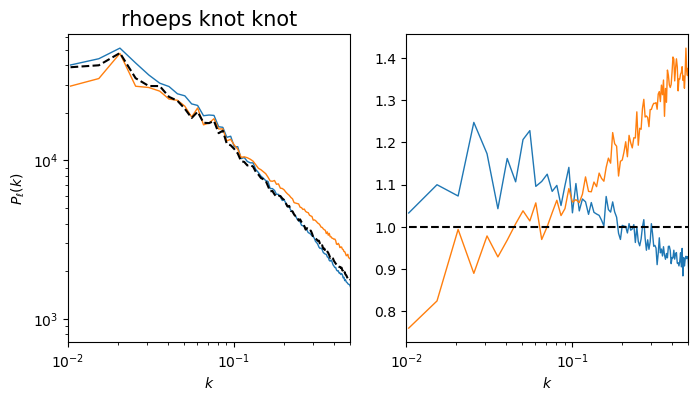

rhoeps knot filament 425828 424688


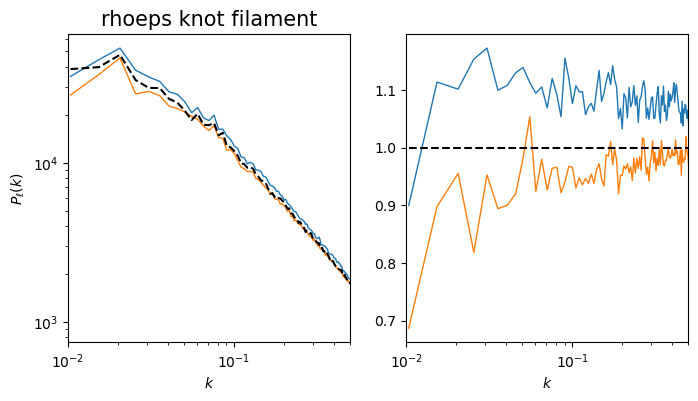

rhoeps knot sheet 426699 425800


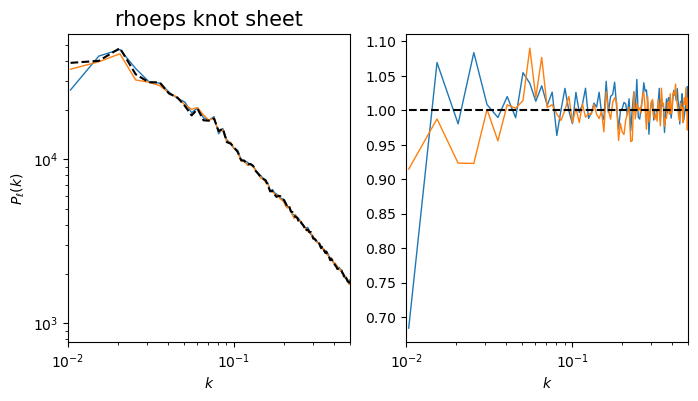

rhoeps knot void 424440 424846


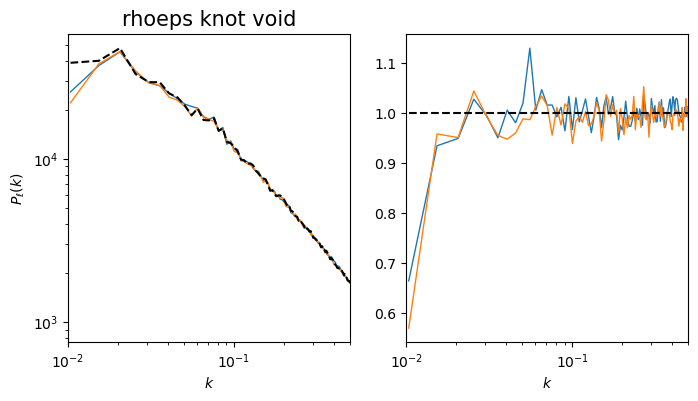

rhoeps filament knot 425126 424663


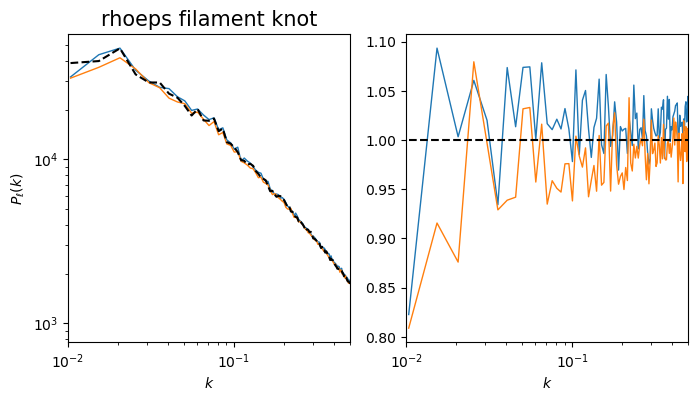

rhoeps filament filament 425420 425205


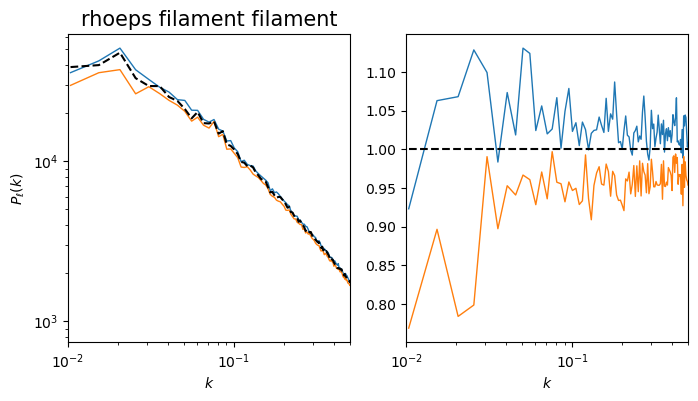

rhoeps filament sheet 424934 423353


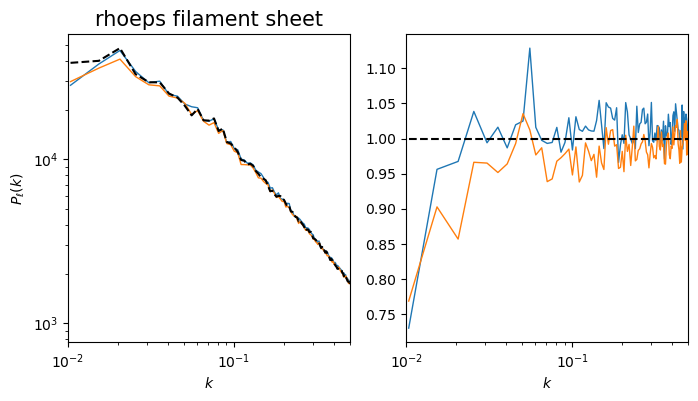

rhoeps filament void 424700 423991


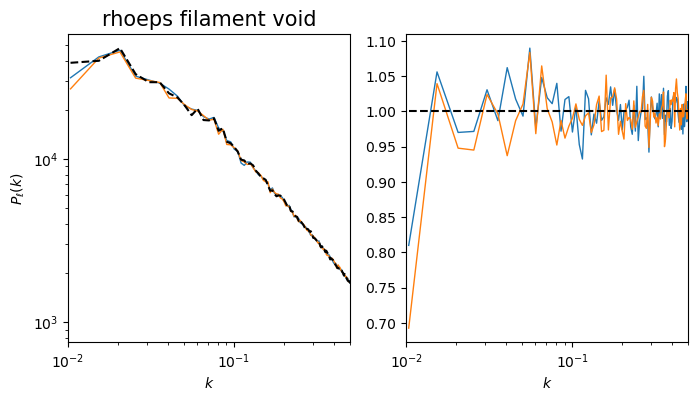

rhoeps sheet knot 424817 425215


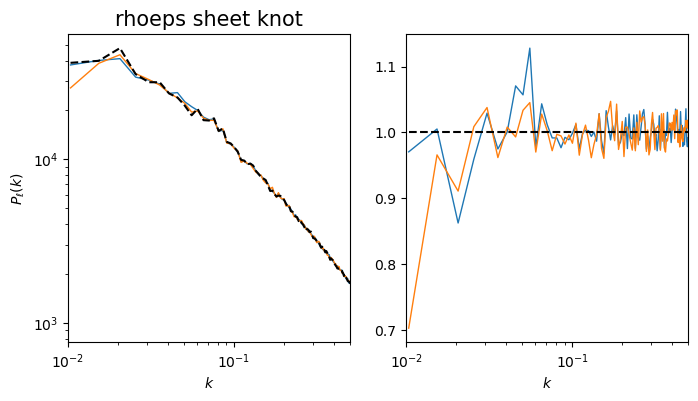

rhoeps sheet filament 424824 425508


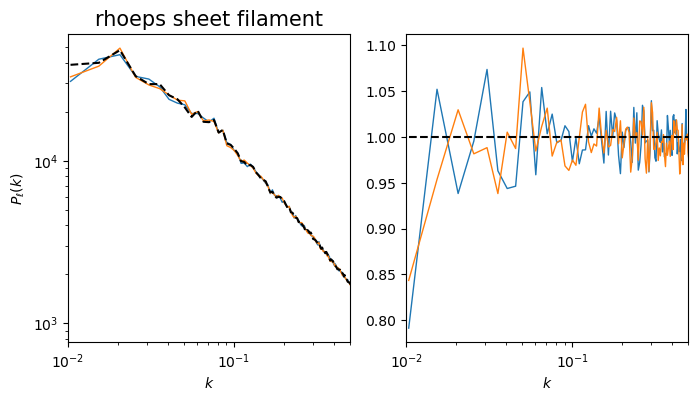

rhoeps sheet sheet 425277 425564


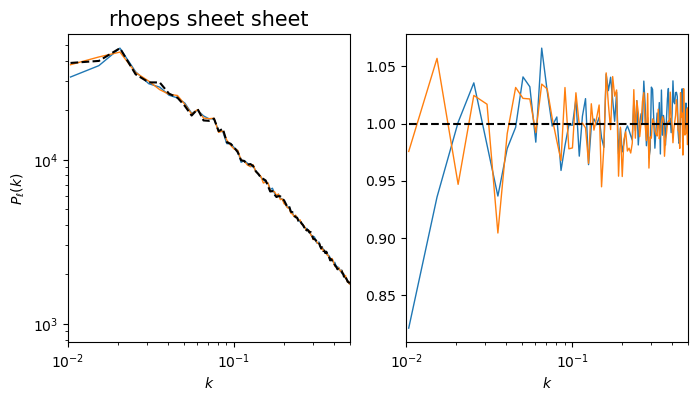

rhoeps sheet void 426739 424358


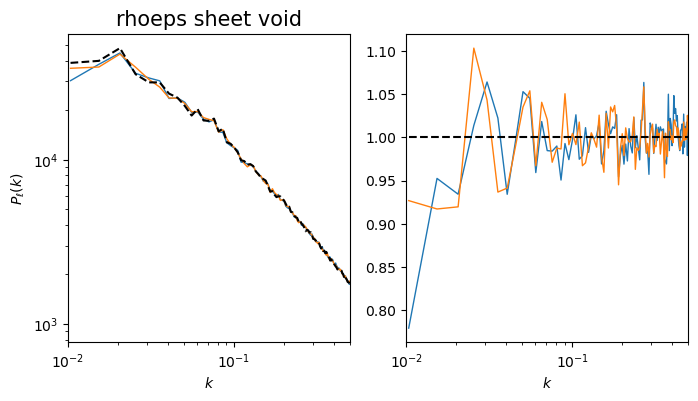

In [18]:
key = 'rhoeps'
for ienv in range(3): 
    for jenv in range(4): 
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 2
        _, _p0k0, _ng0 = alpt_pk(_tt)
    
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 0.5
        _k, _p0k1, _ng1 = alpt_pk(_tt)

        print('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), _ng0, _ng1)
    
        fig = plt.figure(figsize=(8,4))
        sub = fig.add_subplot(121)
        sub.plot(k, _p0k0, c='C0', lw=1)  
        sub.plot(k, _p0k1, c='C1', lw=1)  
        sub.plot(k, p0k_fid, c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        sub.set_ylabel('$P_\ell(k)$')
        sub.set_yscale('log')
        sub.set_title('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), 
                      fontsize=15)
    
        sub = fig.add_subplot(122)
        sub.plot(k, _p0k0/p0k_fid, c='C0', lw=1)  
        sub.plot(k, _p0k1/p0k_fid, c='C1', lw=1)  
        sub.plot(k, np.ones_like(k), c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        plt.show()

eps knot knot 424263 425082


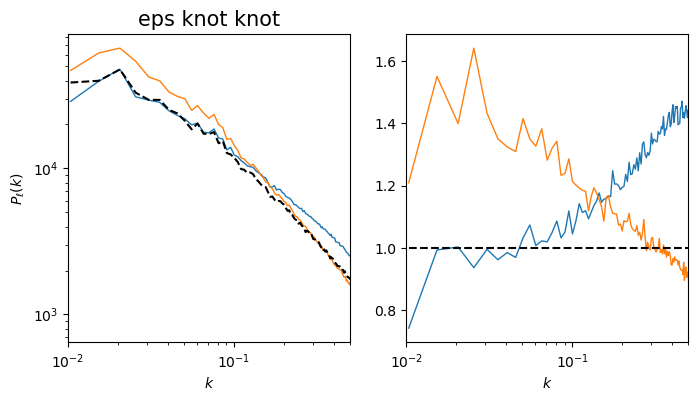

eps knot filament 425093 424270


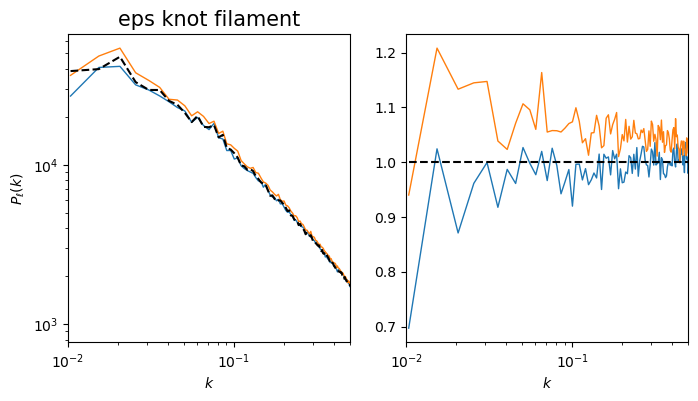

eps knot sheet 425287 425577


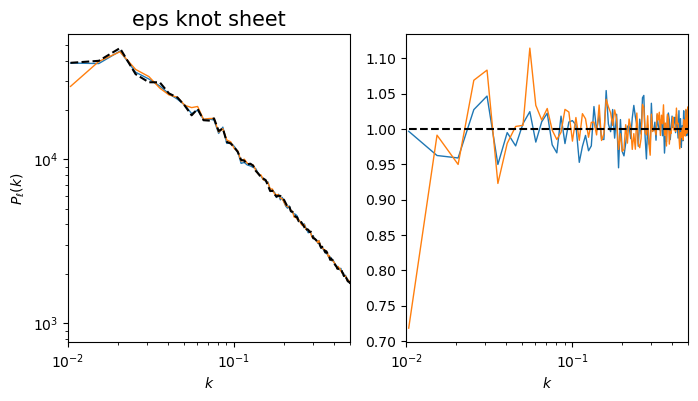

eps knot void 425393 425214


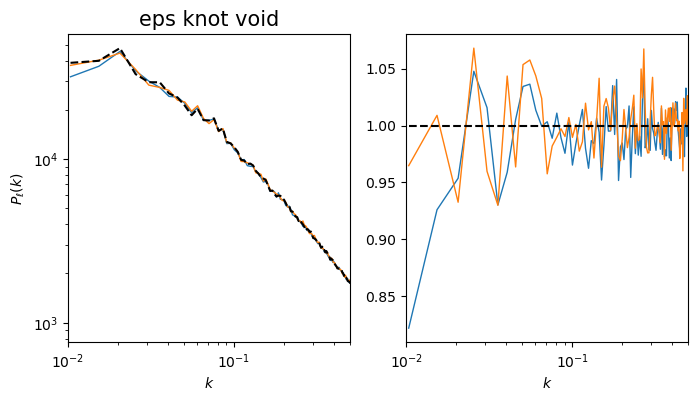

eps filament knot 425641 424432


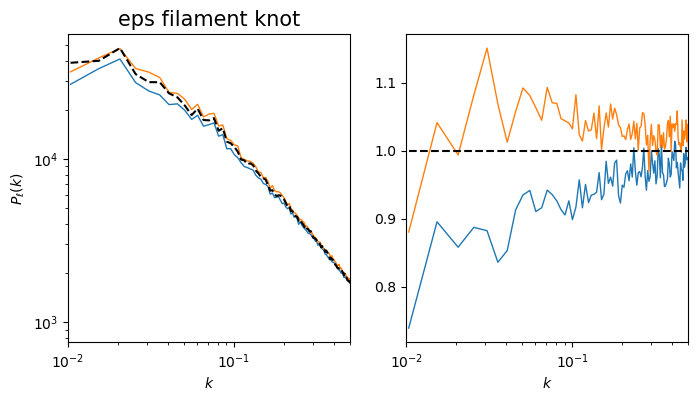

eps filament filament 424863 425498


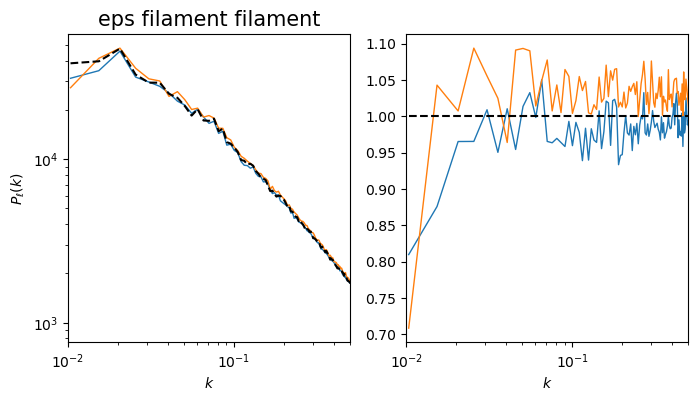

eps filament sheet 424782 424560


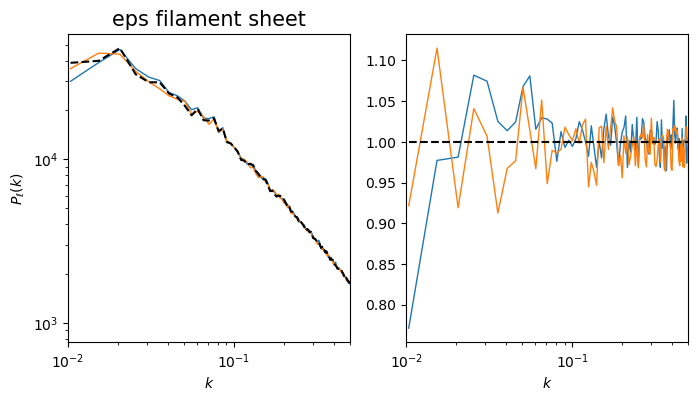

eps filament void 424832 425448


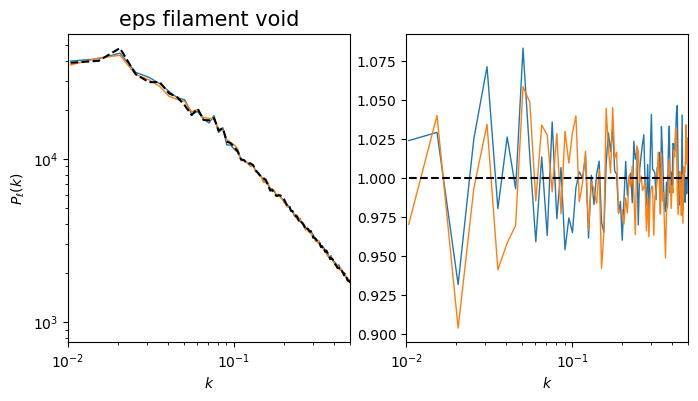

eps sheet knot 426261 425084


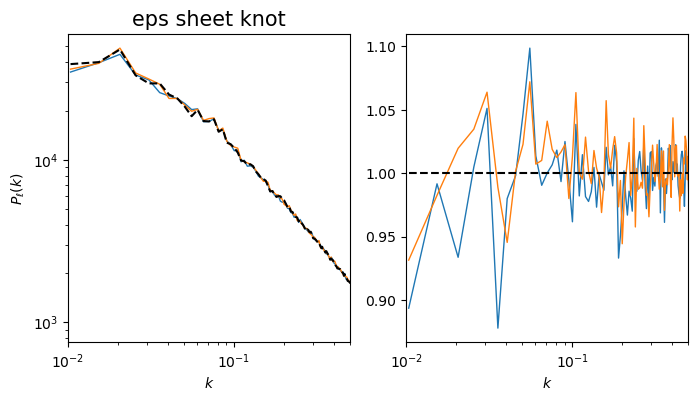

eps sheet filament 423875 424990


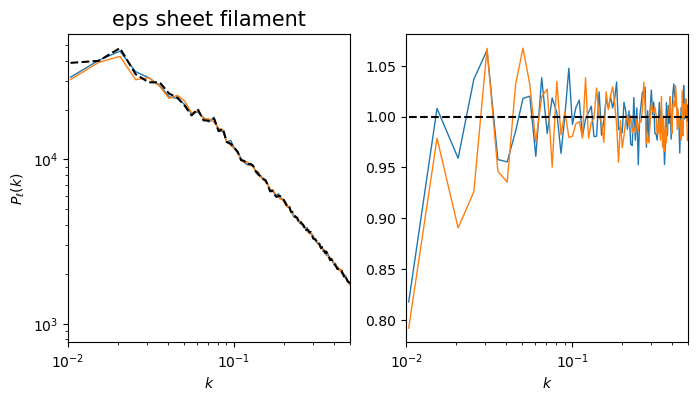

eps sheet sheet 424958 424905


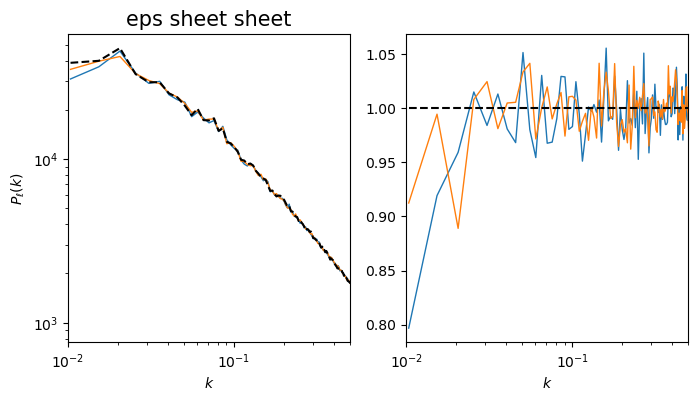

eps sheet void 426095 425220


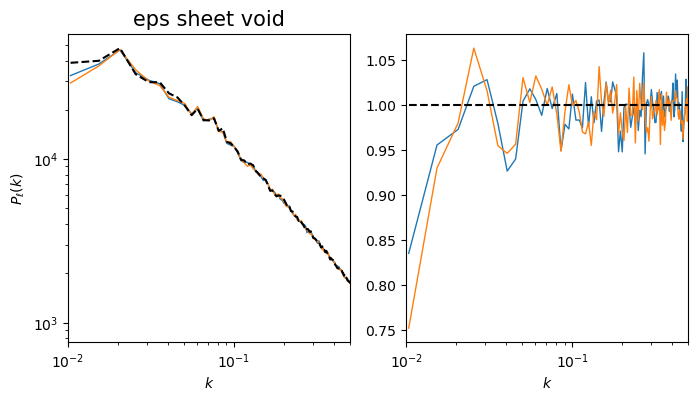

In [19]:
key = 'eps'
for ienv in range(3): 
    for jenv in range(4): 
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 2
        _, _p0k0, _ng0 = alpt_pk(_tt)
    
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 0.5
        _k, _p0k1, _ng1 = alpt_pk(_tt)

        print('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), _ng0, _ng1)
    
        fig = plt.figure(figsize=(8,4))
        sub = fig.add_subplot(121)
        sub.plot(k, _p0k0, c='C0', lw=1)  
        sub.plot(k, _p0k1, c='C1', lw=1)  
        sub.plot(k, p0k_fid, c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        sub.set_ylabel('$P_\ell(k)$')
        sub.set_yscale('log')
        sub.set_title('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), 
                      fontsize=15)
    
        sub = fig.add_subplot(122)
        sub.plot(k, _p0k0/p0k_fid, c='C0', lw=1)  
        sub.plot(k, _p0k1/p0k_fid, c='C1', lw=1)  
        sub.plot(k, np.ones_like(k), c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        plt.show()